# Laboratorio 1: Series de Tiempo
## Series de Tiempo: Regiones Geográficas
### Ingreso de viajeros internacionales a Guatemala (2009 - junio 2026)

**Integrantes:**
- Isabella Recinos Rodríguez - 23003
- Sofía López Ayerdi - 231929
- Nils Muralles Morales - 23727

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA_PATH = "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"

# Mismo estilo visual que en eda.ipynb (paleta categórica fija, validada para daltonismo)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 100,
})

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df["fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango de fechas: {df['fecha'].min().strftime('%Y-%m')} a {df['fecha'].max().strftime('%Y-%m')}")


Dimensiones del dataset: 161,036 filas x 14 columnas
Rango de fechas: 2009-01 a 2026-06


## 1. División en entrenamiento y prueba (Ejercicio 2)

El dataset cubre 210 meses consecutivos (enero 2009 a junio 2026). Para una serie de tiempo la división no puede hacerse al azar, tiene que respetar el orden cronológico: el conjunto de entrenamiento es el tramo más antiguo y el de prueba es el tramo más reciente. Se usa un corte que deja aproximadamente 70% de los meses en entrenamiento y 30% en prueba.

In [74]:
fechas_unicas = sorted(df["fecha"].unique())
n_meses = len(fechas_unicas)
corte_idx = int(n_meses * 0.7) - 1
fecha_corte = fechas_unicas[corte_idx]

train = df[df["fecha"] <= fecha_corte].copy()
test = df[df["fecha"] > fecha_corte].copy()

print(f"Total de meses: {n_meses}")
print(f"Fecha de corte (último mes de entrenamiento): {pd.Timestamp(fecha_corte).strftime('%Y-%m')}")
print()
print(f"Entrenamiento: {train['fecha'].min().strftime('%Y-%m')} a {train['fecha'].max().strftime('%Y-%m')} "
      f"({train['fecha'].nunique()} meses, {train['fecha'].nunique()/n_meses*100:.1f}% del total)")
print(f"Prueba:        {test['fecha'].min().strftime('%Y-%m')} a {test['fecha'].max().strftime('%Y-%m')} "
      f"({test['fecha'].nunique()} meses, {test['fecha'].nunique()/n_meses*100:.1f}% del total)")


Total de meses: 210
Fecha de corte (último mes de entrenamiento): 2021-03

Entrenamiento: 2009-01 a 2021-03 (147 meses, 70.0% del total)
Prueba:        2021-04 a 2026-06 (63 meses, 30.0% del total)


El corte queda en **marzo de 2021**: entrenamiento de enero 2009 a marzo 2021 (147 meses, 70.0%) y prueba de abril 2021 a junio 2026 (63 meses, 30.0%). Es un corte exacto de 70/30 en número de meses. Vale la pena notar que el entrenamiento incluye todo el tramo de crecimiento 2009-2019 y también el colapso de la pandemia (2020 y el primer trimestre de 2021), mientras que el conjunto de prueba cubre casi toda la recuperación posterior. Esto es intencional y no se ajusta a mano: es simplemente dónde cae el 70% de los meses, y como se vio en el EDA, la pandemia es el evento más grande de toda la serie, así que cualquier modelo entrenado con este corte tendrá que lidiar con ese quiebre dentro de los propios datos de entrenamiento.

## 2. Construcción de las series mensuales por región (Ejercicio 3)

Se usa la variable `Región dos`, que en el EDA resultó ser la que agrupa de forma más limpia el territorio en continentes/grandes áreas. Las 3 regiones con mayor acumulado histórico de viajeros (criterio pedido en el enunciado: acumulado de todo el período, no de un año específico) son **América del Centro**, **América del Norte** y **Europa**.

In [75]:
top_regiones_global = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)
top3_regiones = [r for r in top_regiones_global.index if r not in ("0", "Cruceristas", "Cruceros")][:3]
print("Top 3 regiones por acumulado histórico (todo el período 2009-2026):")
top_regiones_global.loc[top3_regiones]


Top 3 regiones por acumulado histórico (todo el período 2009-2026):


Región dos
América Del Centro    3.740653e+07
América Del Norte     9.383035e+06
Europa                2.222621e+06
Name: Viajero, dtype: float64

Se excluyen del ranking las categorías `"Cruceristas"`, `"Cruceros"` y `"0"` porque no son regiones geográficas reales, son ruido de clasificación ya documentado en el EDA. Las series se construyen únicamente con datos del conjunto de **entrenamiento**, sumando `Viajero` por mes y región (recordando el hallazgo del EDA de que hay combinaciones repetidas en 2020-2022 que hay que sumar, no descartar).

In [76]:
rango_train = pd.date_range(train["fecha"].min(), train["fecha"].max(), freq="MS")

series_regiones = {}
for region in top3_regiones:
    s = train[train["Región dos"] == region].groupby("fecha")["Viajero"].sum()
    s = s.reindex(rango_train, fill_value=0.0)
    s.index.name = "fecha"
    series_regiones[region] = s

resumen = pd.DataFrame({r: s.describe() for r, s in series_regiones.items()})
resumen.round(1)


,América Del Centro,América Del Norte,Europa
count,147.0,147.0,147.0
mean,171622.4,39235.3,9876.8
std,81608.3,14167.4,3875.5
min,9779.0,0.0,0.0
25%,117740.0,33207.0,7527.8
50%,153282.1,39721.0,10352.0
75%,232534.9,48953.6,12659.5
max,414729.0,69215.6,16804.0


In [77]:
for region, s in series_regiones.items():
    meses_en_cero = (s == 0).sum()
    print(f"{region}: {meses_en_cero} mes(es) con 0 viajeros registrados", end="")
    if meses_en_cero:
        print(" ->", [d.strftime('%Y-%m') for d in s[s == 0].index.tolist()])
    else:
        print()


América Del Centro: 0 mes(es) con 0 viajeros registrados
América Del Norte: 5 mes(es) con 0 viajeros registrados -> ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']
Europa: 5 mes(es) con 0 viajeros registrados -> ['2020-04', '2020-05', '2020-06', '2020-07', '2020-08']


**América del Centro** nunca llega a cero, ni en el peor mes de la pandemia. **América del Norte** y **Europa**, en cambio, tienen **5 meses (abril a agosto de 2020) con exactamente 0 filas en el dataset**, es decir, no se registró ni un solo viajero de esas regiones en esos meses. No es un hueco de captura de datos: coincide exactamente con el cierre total de fronteras al inicio de la pandemia, cuando el turismo internacional de larga distancia se detuvo por completo, mientras que el tránsito terrestre centroamericano (comercio, retorno de connacionales) nunca se detuvo del todo. Esta es la primera evidencia concreta de que **la pandemia no golpeó por igual a las 3 regiones**, algo que se retoma en cada subsección de estacionariedad y en el análisis comparativo de la entrega final.

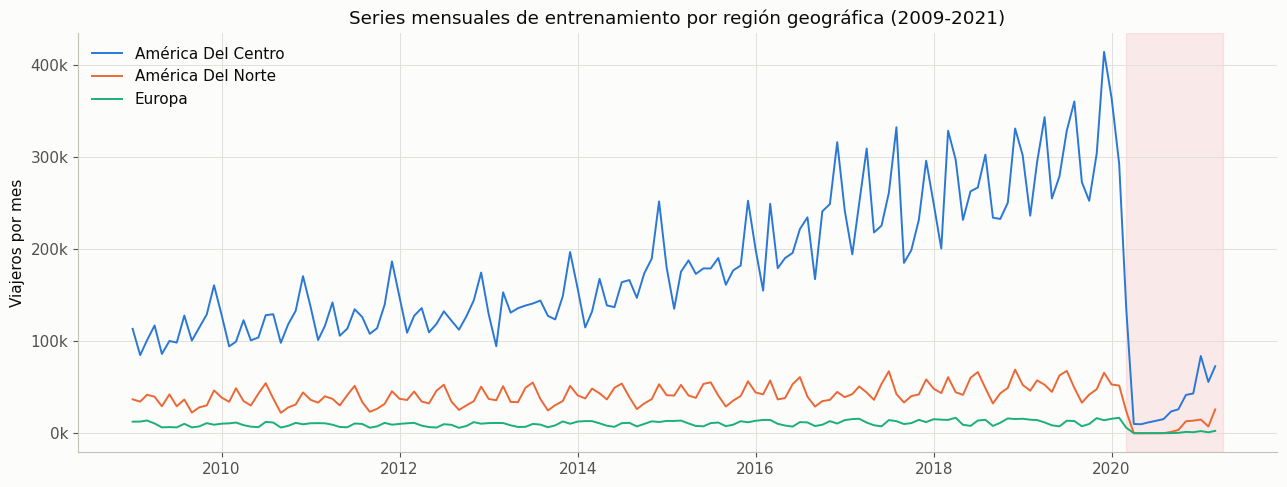

In [78]:
fig, ax = plt.subplots(figsize=(13, 5))
for i, (region, s) in enumerate(series_regiones.items()):
    ax.plot(s.index, s.values, color=PALETTE[i], linewidth=1.4, label=region)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-03-31"), color=PALETTE[7], alpha=0.10)
ax.set_title("Series mensuales de entrenamiento por región geográfica (2009-2021)")
ax.set_ylabel("Viajeros por mes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Las 3 series comparten el mismo patrón general (crecimiento 2009-2019, colapso en la pandemia), pero a escalas muy distintas: América del Centro está un orden de magnitud por encima de América del Norte, y esta a su vez varias veces por encima de Europa. Por eso en las siguientes subsecciones cada serie se analiza por separado, ya que graficarlas juntas en la misma escala esconde el detalle de las dos series más pequeñas.

## 3. Análisis de cada serie (Ejercicio 4, incisos a-e)

Se analiza cada una de las 3 series por separado: inicio/fin/frecuencia, gráfico, descomposición, discusión de estacionariedad en media y varianza, necesidad de transformación, y confirmación de no estacionariedad en media con ACF y la prueba de Dickey-Fuller Aumentada (ADF).

### 3.1 América del Centro

#### a. Inicio, fin y frecuencia

In [79]:
s_centro = series_regiones["América Del Centro"]
print(f"Inicio: {s_centro.index.min().strftime('%Y-%m')}")
print(f"Fin: {s_centro.index.max().strftime('%Y-%m')}")
print(f"Frecuencia: mensual (MS), {len(s_centro)} observaciones, sin huecos")


Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual (MS), 147 observaciones, sin huecos


#### b. Gráfico de la serie

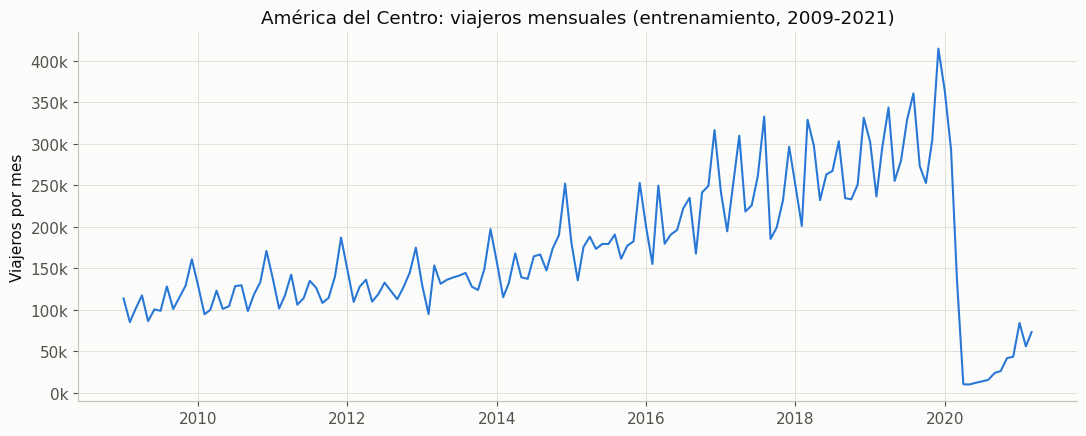

In [80]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(s_centro.index, s_centro.values, color=PALETTE[0], linewidth=1.5)
ax.set_title("América del Centro: viajeros mensuales (entrenamiento, 2009-2021)")
ax.set_ylabel("Viajeros por mes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()


A primera vista se ve una **tendencia de crecimiento sostenido** entre 2009 y 2019, con oscilaciones estacionales regulares dentro de cada año, y luego una **caída abrupta a partir de marzo de 2020** que lleva la serie a su mínimo histórico (poco más de 9,700 viajeros en un mes, frente a un máximo de casi 415,000). A diferencia de lo que se verá en América del Norte y Europa, la serie **nunca toca cero**: el flujo terrestre centroamericano se redujo muchísimo pero no se detuvo del todo durante la pandemia.

#### c. Descomposición de la serie

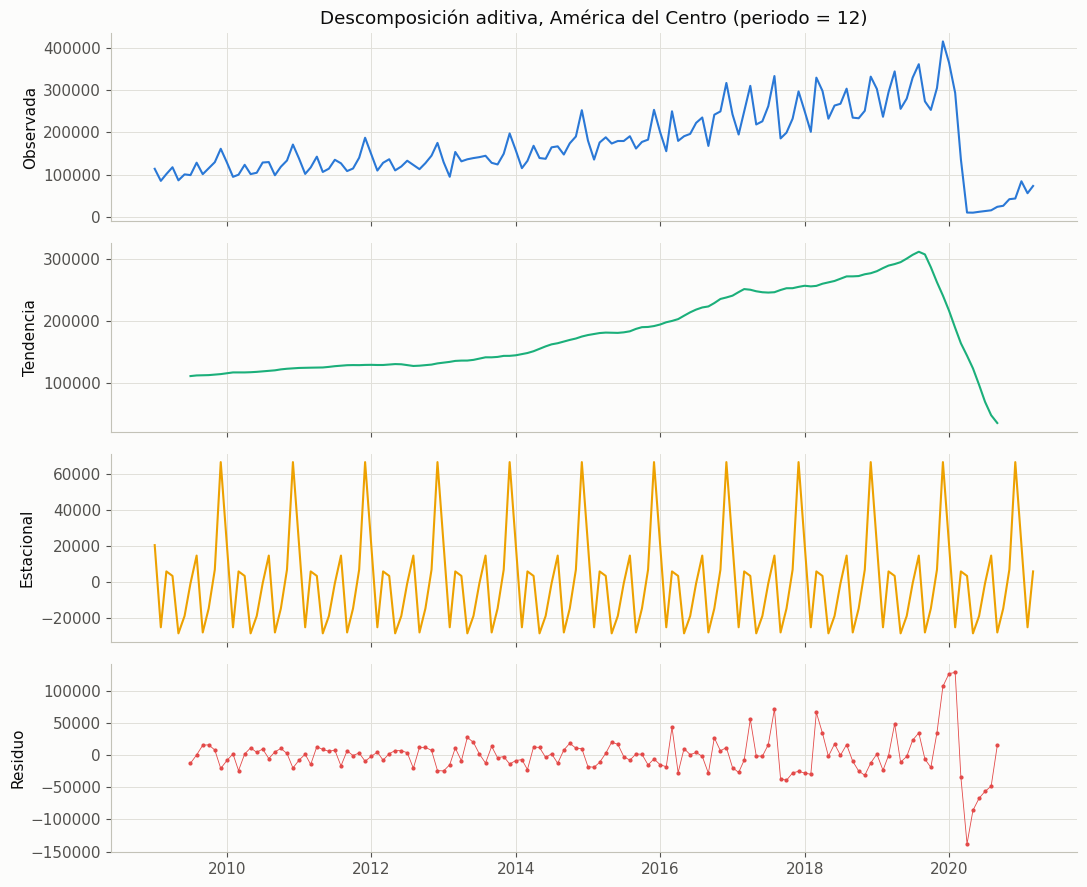

In [81]:
decomp_centro = seasonal_decompose(s_centro, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s_centro.index, decomp_centro.observed, color=PALETTE[0])
axes[0].set_ylabel("Observada")
axes[1].plot(s_centro.index, decomp_centro.trend, color=PALETTE[2])
axes[1].set_ylabel("Tendencia")
axes[2].plot(s_centro.index, decomp_centro.seasonal, color=PALETTE[3])
axes[2].set_ylabel("Estacional")
axes[3].plot(s_centro.index, decomp_centro.resid, color=PALETTE[7], marker="o", markersize=2, linewidth=0.6)
axes[3].set_ylabel("Residuo")
axes[0].set_title("Descomposición aditiva, América del Centro (periodo = 12)")
plt.tight_layout()
plt.show()


El componente de **tendencia** confirma el crecimiento sostenido hasta 2019 y el desplome en 2020, sin recuperación dentro del tramo de entrenamiento (que termina en marzo 2021, todavía en plena pandemia). El componente **estacional** muestra un patrón que se repite cada 12 meses (consistente con el pico de diciembre visto en el EDA). El **residuo** es pequeño y relativamente estable durante el período de crecimiento, pero se dispara justo en 2020, ya que la caída es tan brusca que ni la tendencia ni el componente estacional logran capturarla del todo.

**Estacionariedad en media:** la serie **no es estacionaria en media**. Hay una tendencia clara y persistente (creciente y luego decreciente), no hay un nivel promedio constante al que la serie regrese.

**Estacionariedad en varianza:** tampoco parece estacionaria en varianza a simple vista, los picos y valles estacionales son mucho más amplios (en términos absolutos) en 2018-2019 que en 2009-2010, lo que sugiere que la dispersión crece junto con el nivel de la serie. Esto se confirma numéricamente en el siguiente inciso.

#### d. ¿Es necesaria una transformación?

In [82]:
pre_pandemia = s_centro["2009":"2019"]
anual = pre_pandemia.groupby(pre_pandemia.index.year).agg(["mean", "std"])
corr_nivel = anual["mean"].corr(anual["std"])

log_s = np.log1p(pre_pandemia)
anual_log = log_s.groupby(log_s.index.year).agg(["mean", "std"])
corr_log = anual_log["mean"].corr(anual_log["std"])

print("Media y desviación estándar por año (2009-2019, antes de la pandemia):")
display(anual.round(0))
print(f"\nCorrelación entre media y desviación anual (escala original): {corr_nivel:.3f}")
print(f"Correlación entre media y desviación anual (escala log): {corr_log:.3f}")


Media y desviación estándar por año (2009-2019, antes de la pandemia):


,mean,std
fecha,,
2009,111271.0,21163.0
2010,119088.0,21627.0
2011,127333.0,23458.0
2012,130334.0,18910.0
2013,138836.0,23750.0
2014,161869.0,35117.0
2015,181260.0,26780.0
2016,216862.0,44762.0
2017,245603.0,47007.0



Correlación entre media y desviación anual (escala original): 0.934
Correlación entre media y desviación anual (escala log): 0.017


La correlación entre el nivel promedio anual y su dispersión es de **0.93 en la escala original**, prácticamente una relación lineal: a mayor nivel, mayor variabilidad. Al aplicar una **transformación logarítmica** (`log1p`), esa correlación cae a **0.02**, es decir, casi desaparece. Esto confirma que **sí conviene transformar la serie con logaritmo** antes de modelarla, para estabilizar la varianza. La transformación log es la recomendada para esta serie.

#### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

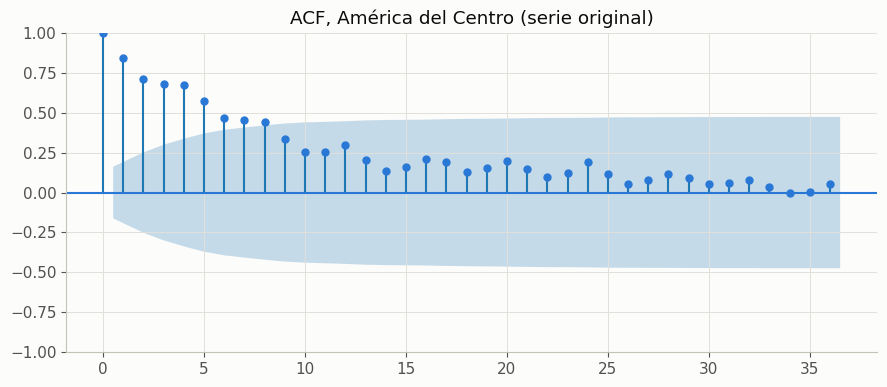

In [83]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_acf(s_centro, lags=36, ax=ax, color=PALETTE[0])
ax.set_title("ACF, América del Centro (serie original)")
plt.tight_layout()
plt.show()


El correlograma muestra autocorrelaciones **altas y con una caída muy lenta** a medida que aumenta el rezago (lag), en vez de desvanecerse rápido hacia cero. Esa caída lenta es la firma clásica de una serie **no estacionaria en media**: cada valor está fuertemente relacionado con sus vecinos cercanos en el tiempo, señal de que hay una tendencia (o una raíz unitaria) y no un nivel promedio fijo.

In [84]:
adf_nivel = adfuller(s_centro, autolag="AIC")
print(f"ADF (nivel):      estadístico = {adf_nivel[0]:.3f}   p-valor = {adf_nivel[1]:.4f}")

diff1_centro = s_centro.diff().dropna()
adf_diff1 = adfuller(diff1_centro, autolag="AIC")
print(f"ADF (1ª diferencia): estadístico = {adf_diff1[0]:.3f}   p-valor = {adf_diff1[1]:.4f}")


ADF (nivel):      estadístico = -1.854   p-valor = 0.3540
ADF (1ª diferencia): estadístico = -3.359   p-valor = 0.0124


Con un nivel de significancia usual del 5%, el p-valor de la prueba ADF en el nivel de la serie (0.354) **no permite rechazar la hipótesis nula de raíz unitaria**, así que se confirma estadísticamente que la serie **no es estacionaria en media**. Al aplicar una **primera diferencia** (restar a cada mes el valor del mes anterior), el p-valor baja a 0.012, por debajo de 0.05, y ahí sí se rechaza la raíz unitaria. **Con una diferenciación regular (d = 1) la serie de América del Centro se vuelve estacionaria en media.** La elección final de p, d, q para el modelo ARIMA se hará en la siguiente entrega con ayuda del ACF/PACF de la serie ya diferenciada (y transformada con logaritmo).

### 3.2 América del Norte

#### a. Inicio, fin y frecuencia

In [85]:
s_norte = series_regiones["América Del Norte"]
print(f"Inicio: {s_norte.index.min().strftime('%Y-%m')}")
print(f"Fin: {s_norte.index.max().strftime('%Y-%m')}")
print(f"Frecuencia: mensual (MS), {len(s_norte)} observaciones, sin huecos (los meses sin viajeros registrados se completaron con 0)")


Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual (MS), 147 observaciones, sin huecos (los meses sin viajeros registrados se completaron con 0)


#### b. Gráfico de la serie

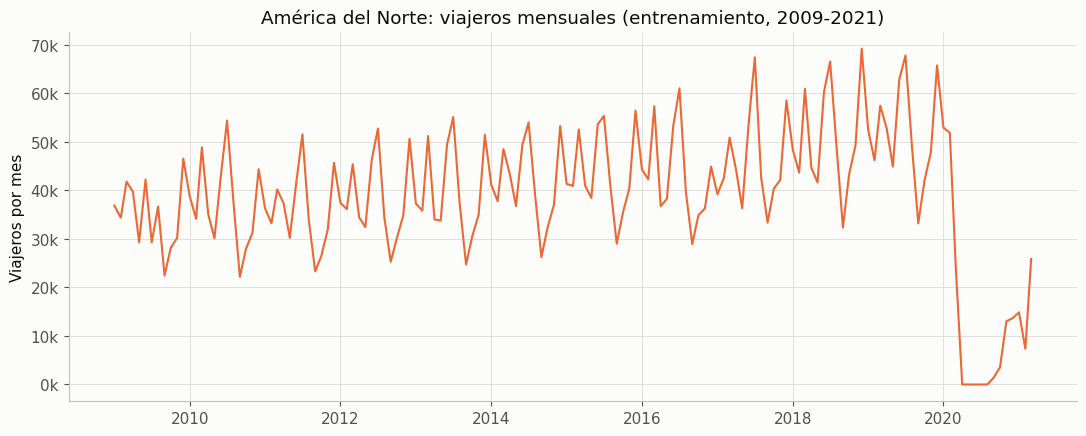

In [86]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(s_norte.index, s_norte.values, color=PALETTE[1], linewidth=1.5)
ax.set_title("América del Norte: viajeros mensuales (entrenamiento, 2009-2021)")
ax.set_ylabel("Viajeros por mes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()


Al igual que América del Centro, hay una tendencia de crecimiento entre 2009 y 2019 con una estacionalidad anual visible. La diferencia importante es la caída de 2020: la serie **llega exactamente a 0** durante abril, mayo, junio, julio y agosto de ese año, el único de los tres grupos regionales que toca el piso absoluto. Esto es coherente con que este flujo depende casi por completo de la vía aérea (turismo de Estados Unidos y Canadá), que se detuvo por completo cuando cerraron los aeropuertos, mientras que el flujo terrestre centroamericano de la sección anterior nunca llegó a cero.

#### c. Descomposición de la serie

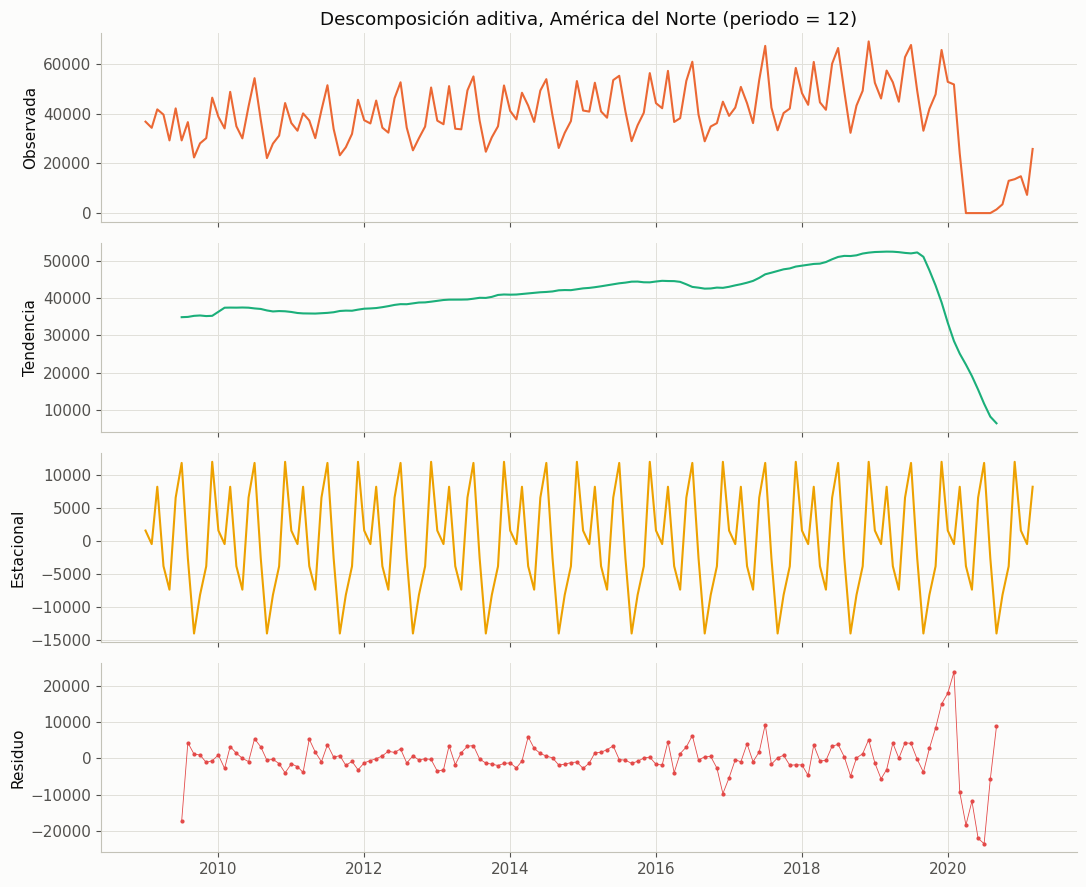

In [87]:
decomp_norte = seasonal_decompose(s_norte, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s_norte.index, decomp_norte.observed, color=PALETTE[1])
axes[0].set_ylabel("Observada")
axes[1].plot(s_norte.index, decomp_norte.trend, color=PALETTE[2])
axes[1].set_ylabel("Tendencia")
axes[2].plot(s_norte.index, decomp_norte.seasonal, color=PALETTE[3])
axes[2].set_ylabel("Estacional")
axes[3].plot(s_norte.index, decomp_norte.resid, color=PALETTE[7], marker="o", markersize=2, linewidth=0.6)
axes[3].set_ylabel("Residuo")
axes[0].set_title("Descomposición aditiva, América del Norte (periodo = 12)")
plt.tight_layout()
plt.show()


La tendencia repite el patrón de crecimiento y colapso ya visto. Lo más notorio es el **residuo**: se dispara con mucha más fuerza que en América del Centro justo en los meses de cero absoluto, porque ni la tendencia ni la estacionalidad estimadas por el modelo aditivo pueden anticipar una caída a cero tan repentina. Esto es evidencia adicional (más allá del ADF) de que **2020 se comporta como un evento estructural**, no como una fluctuación estacional más.

**Estacionariedad en media:** no es estacionaria, la tendencia cambia de dirección de forma marcada.

**Estacionariedad en varianza:** los picos estacionales también se amplifican con el nivel (más grandes en 2018-2019 que en 2009-2010), lo que apunta otra vez a heterocedasticidad.

#### d. ¿Es necesaria una transformación?

In [88]:
pre_pandemia_n = s_norte["2009":"2019"]
anual_n = pre_pandemia_n.groupby(pre_pandemia_n.index.year).agg(["mean", "std"])
corr_nivel_n = anual_n["mean"].corr(anual_n["std"])

log_n = np.log1p(pre_pandemia_n)
anual_log_n = log_n.groupby(log_n.index.year).agg(["mean", "std"])
corr_log_n = anual_log_n["mean"].corr(anual_log_n["std"])

print(f"Correlación media-desviación anual (escala original): {corr_nivel_n:.3f}")
print(f"Correlación media-desviación anual (escala log): {corr_log_n:.3f}")


Correlación media-desviación anual (escala original): 0.833
Correlación media-desviación anual (escala log): -0.463


La correlación entre nivel y dispersión anual es de **0.83** en la escala original, y cae a **-0.46** después de aplicar logaritmo. El logaritmo sobrecorrige un poco (correlación negativa) pero en magnitud es mucho menor que 0.83, así que sigue siendo una mejora clara. **Se recomienda transformar con logaritmo** antes de modelar, igual que en América del Centro.

#### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

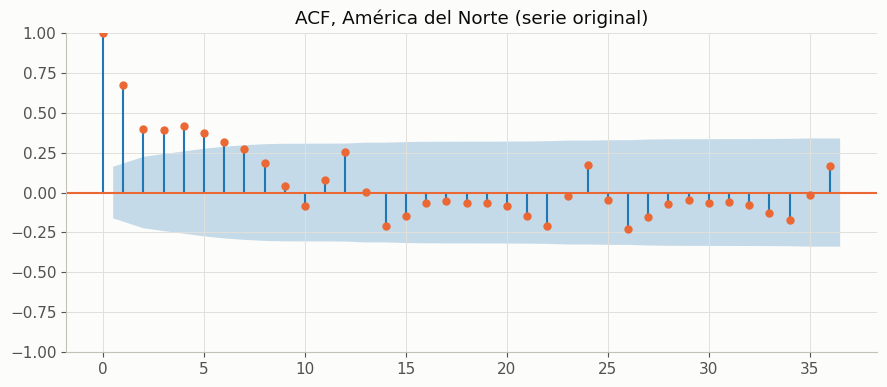

In [89]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_acf(s_norte, lags=36, ax=ax, color=PALETTE[1])
ax.set_title("ACF, América del Norte (serie original)")
plt.tight_layout()
plt.show()


El ACF también decae lentamente, con autocorrelaciones significativas hasta rezagos altos, lo que otra vez es indicio visual de no estacionariedad en media.

In [90]:
adf_nivel_n = adfuller(s_norte, autolag="AIC")
print(f"ADF (nivel):      estadístico = {adf_nivel_n[0]:.3f}   p-valor = {adf_nivel_n[1]:.4f}")

diff1_norte = s_norte.diff().dropna()
adf_diff1_n = adfuller(diff1_norte, autolag="AIC")
print(f"ADF (1ª diferencia): estadístico = {adf_diff1_n[0]:.3f}   p-valor = {adf_diff1_n[1]:.4f}")


ADF (nivel):      estadístico = -3.216   p-valor = 0.0191
ADF (1ª diferencia): estadístico = -3.309   p-valor = 0.0145


Aquí el resultado merece una lectura cuidadosa: la prueba ADF en el **nivel** de la serie da un p-valor de **0.019**, que técnicamente está por debajo del umbral usual de 0.05 y llevaría a rechazar la hipótesis de raíz unitaria. Sin embargo, esto **no significa que la serie sea estacionaria en el sentido útil para modelar**: la prueba ADF puede confundirse cuando hay un quiebre estructural muy marcado como la caída a cero de 2020, ese salto abrupto puede hacer que el estadístico de prueba se comporte como si hubiera "reversión a la media" sin que en realidad exista un nivel promedio estable. Dado que el gráfico y la descomposición muestran con claridad una tendencia de crecimiento 2009-2019 seguida de un colapso, se recomienda **no confiar únicamente en este p-valor** y tratar la serie como no estacionaria en media, igual que las otras dos. Con la primera diferencia el p-valor baja aún más (0.015) y el resultado es más robusto, por lo que **se recomienda igualmente usar d = 1** para esta serie antes de modelar.

### 3.3 Europa

#### a. Inicio, fin y frecuencia

In [91]:
s_europa = series_regiones["Europa"]
print(f"Inicio: {s_europa.index.min().strftime('%Y-%m')}")
print(f"Fin: {s_europa.index.max().strftime('%Y-%m')}")
print(f"Frecuencia: mensual (MS), {len(s_europa)} observaciones, sin huecos (los meses sin viajeros registrados se completaron con 0)")


Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual (MS), 147 observaciones, sin huecos (los meses sin viajeros registrados se completaron con 0)


#### b. Gráfico de la serie

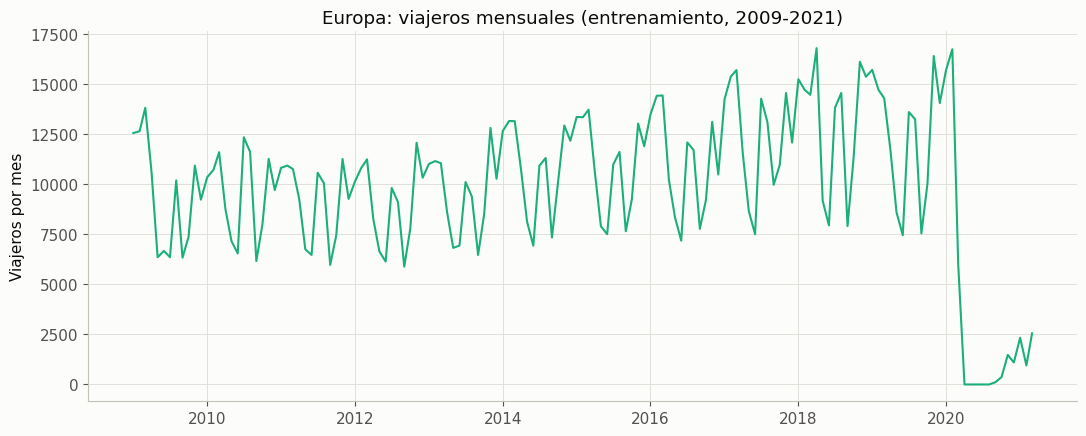

In [92]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(s_europa.index, s_europa.values, color=PALETTE[2], linewidth=1.5)
ax.set_title("Europa: viajeros mensuales (entrenamiento, 2009-2021)")
ax.set_ylabel("Viajeros por mes")
plt.tight_layout()
plt.show()


Es la más pequeña de las 3 series en volumen (máximo de casi 16,800 viajeros en un mes, contra más de 400,000 de América del Centro), pero muestra la **estacionalidad más marcada y más regular** de las tres: los picos y valles dentro de cada año son proporcionalmente más grandes, coherente con que el turismo europeo depende de temporadas vacacionales concentradas (verano e invierno boreal) y de vuelos de larga distancia, no de un flujo fronterizo constante. También llega a 0 en abril-agosto de 2020, igual que América del Norte.

#### c. Descomposición de la serie

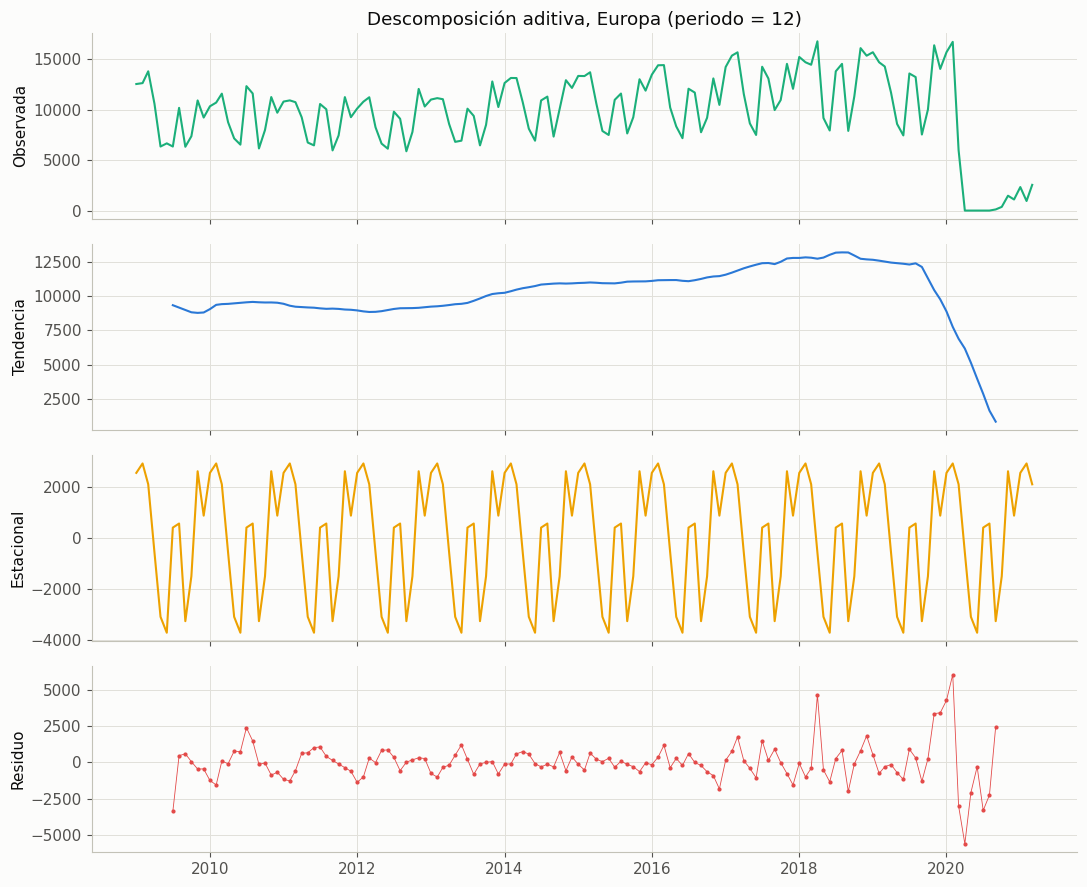

In [93]:
decomp_europa = seasonal_decompose(s_europa, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s_europa.index, decomp_europa.observed, color=PALETTE[2])
axes[0].set_ylabel("Observada")
axes[1].plot(s_europa.index, decomp_europa.trend, color=PALETTE[0])
axes[1].set_ylabel("Tendencia")
axes[2].plot(s_europa.index, decomp_europa.seasonal, color=PALETTE[3])
axes[2].set_ylabel("Estacional")
axes[3].plot(s_europa.index, decomp_europa.resid, color=PALETTE[7], marker="o", markersize=2, linewidth=0.6)
axes[3].set_ylabel("Residuo")
axes[0].set_title("Descomposición aditiva, Europa (periodo = 12)")
plt.tight_layout()
plt.show()


La tendencia crece de forma más moderada que en las otras dos regiones (casi plana entre 2009 y 2013, y con más pendiente después), y se desploma igual en 2020. El componente estacional tiene la amplitud proporcionalmente más grande de las tres series, lo que confirma lo observado en el gráfico. El residuo vuelve a dispararse en los meses de cero absoluto.

**Estacionariedad en media:** no es estacionaria, hay tendencia.

**Estacionariedad en varianza:** tampoco, la amplitud estacional crece junto con el nivel en los años de mayor crecimiento (2017-2019).

#### d. ¿Es necesaria una transformación?

In [94]:
pre_pandemia_e = s_europa["2009":"2019"]
anual_e = pre_pandemia_e.groupby(pre_pandemia_e.index.year).agg(["mean", "std"])
corr_nivel_e = anual_e["mean"].corr(anual_e["std"])

log_e = np.log1p(pre_pandemia_e)
anual_log_e = log_e.groupby(log_e.index.year).agg(["mean", "std"])
corr_log_e = anual_log_e["mean"].corr(anual_log_e["std"])

print(f"Correlación media-desviación anual (escala original): {corr_nivel_e:.3f}")
print(f"Correlación media-desviación anual (escala log): {corr_log_e:.3f}")


Correlación media-desviación anual (escala original): 0.817
Correlación media-desviación anual (escala log): 0.215


La correlación entre nivel y dispersión anual es **0.82** en escala original y baja a **0.22** con logaritmo. **Se recomienda transformar con logaritmo**, igual que las dos series anteriores.

#### e. No estacionariedad en media: ACF y prueba de Dickey-Fuller Aumentada

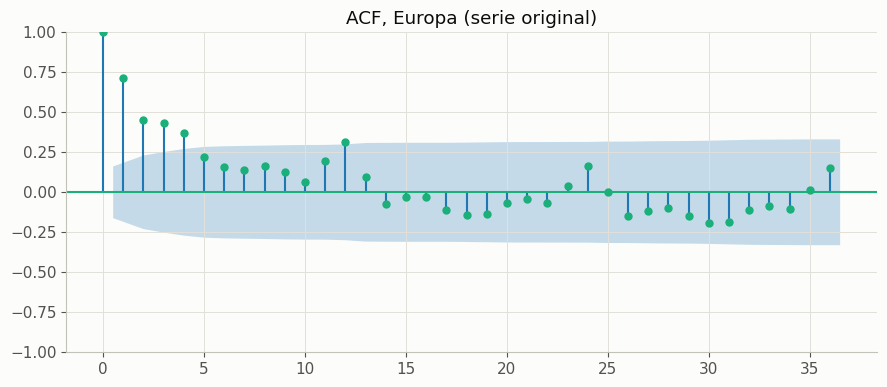

In [95]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_acf(s_europa, lags=36, ax=ax, color=PALETTE[2])
ax.set_title("ACF, Europa (serie original)")
plt.tight_layout()
plt.show()


El correlograma muestra el mismo patrón de decaimiento lento visto en las otras dos regiones, con la particularidad de que se alcanzan a notar repuntes alrededor del rezago 12 (y sus múltiplos), reflejo de la estacionalidad anual más marcada de esta serie.

In [96]:
adf_nivel_e = adfuller(s_europa, autolag="AIC")
print(f"ADF (nivel):         estadístico = {adf_nivel_e[0]:.3f}   p-valor = {adf_nivel_e[1]:.4f}")

diff1_europa = s_europa.diff().dropna()
adf_diff1_e = adfuller(diff1_europa, autolag="AIC")
print(f"ADF (1ª diferencia): estadístico = {adf_diff1_e[0]:.3f}   p-valor = {adf_diff1_e[1]:.4f}")

diff2_europa = s_europa.diff().diff().dropna()
adf_diff2_e = adfuller(diff2_europa, autolag="AIC")
print(f"ADF (2ª diferencia): estadístico = {adf_diff2_e[0]:.3f}   p-valor = {adf_diff2_e[1]:.4f}")

sdiff_europa = s_europa.diff(12).diff().dropna()
adf_sdiff_e = adfuller(sdiff_europa, autolag="AIC")
print(f"ADF (diferencia estacional de 12 + 1ª diferencia regular): estadístico = {adf_sdiff_e[0]:.3f}   p-valor = {adf_sdiff_e[1]:.4f}")


ADF (nivel):         estadístico = -2.116   p-valor = 0.2381
ADF (1ª diferencia): estadístico = -1.557   p-valor = 0.5049
ADF (2ª diferencia): estadístico = -8.855   p-valor = 0.0000
ADF (diferencia estacional de 12 + 1ª diferencia regular): estadístico = -4.363   p-valor = 0.0003


El p-valor en el nivel (0.238) confirma que la serie **no es estacionaria en media**. Lo interesante es que, a diferencia de las otras dos regiones, **una sola diferencia regular no basta**: el p-valor después de la primera diferencia sigue siendo alto (0.505), así que **no se puede rechazar la raíz unitaria con d = 1**. Al aplicar una segunda diferencia regular el p-valor cae a un valor prácticamente cero, y una combinación de diferencia estacional (de orden 12, para remover la estacionalidad marcada que se vio en el ACF) seguida de una diferencia regular también logra estacionariedad (p-valor 0.0003). Esto sugiere que **Europa necesitará un tratamiento distinto a las otras dos series**, probablemente una diferenciación estacional (D = 1, periodo 12) además de la regular, en línea con lo que se observó en el ACF. La elección final entre estas alternativas (d = 2 vs. diferenciación estacional) se hará al construir el modelo SARIMA en la siguiente entrega, comparando AIC/BIC como pide el enunciado.

## 4. Resumen de estacionariedad por serie

| Región | ADF nivel (p-valor) | ¿Estacionaria en media? | Transformación recomendada | Diferenciación sugerida | Afectación por pandemia |
|---|---|---|---|---|---|
| América del Centro | 0.354 | No | Logaritmo | d = 1 | Fuerte caída, pero nunca llega a 0 |
| América del Norte | 0.019* | No (ver nota) | Logaritmo | d = 1 | La más severa: 5 meses en 0 absoluto |
| Europa | 0.238 | No | Logaritmo | Requiere más que d = 1 (d = 2 o diferenciación estacional) | 5 meses en 0 absoluto, mayor estacionalidad relativa |

\* Para América del Norte el ADF en nivel roza el umbral de 0.05 por el quiebre estructural de 2020, no porque la serie sea realmente estable; se trata igual como no estacionaria por evidencia visual y de descomposición.

Las 3 series comparten tendencia de crecimiento 2009-2019 y colapso en la pandemia, y las 3 se benefician de una transformación logarítmica para estabilizar la varianza. La diferencia principal está en la severidad del golpe de la pandemia (América del Centro nunca llega a 0, las otras dos sí) y en la estructura de estacionalidad (Europa parece necesitar diferenciación estacional, algo que se confirmará al construir los modelos SARIMA/ARIMA en la siguiente entrega).

## 5. Selección y comparación de modelos (Ejercicio 4, incisos f-k)

In [97]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    PROPHET_OK = False
    print("Prophet no está instalado; se omitirá ese modelo (pip install prophet).")

In [98]:
rango_test = pd.date_range(test["fecha"].min(), test["fecha"].max(), freq="MS")

series_regiones_test = {}
for region in top3_regiones:
    s = test[test["Región dos"] == region].groupby("fecha")["Viajero"].sum()
    s = s.reindex(rango_test, fill_value=0.0)
    s.index.name = "fecha"
    series_regiones_test[region] = s

s_centro_test = series_regiones_test["América Del Centro"]
s_norte_test  = series_regiones_test["América Del Norte"]
s_europa_test = series_regiones_test["Europa"]

H = len(rango_test)
print(f"Horizonte de pronóstico (meses de prueba): {H}")

Horizonte de pronóstico (meses de prueba): 63


Funciones auxiliares

In [99]:
def graficar_pacf(serie, color, titulo):
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_pacf(serie, lags=36, ax=ax, method="ywm", color=color)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


def probar_candidatos_arima(serie, ordenes, nombre_serie):
    """
    Ajusta varios ARIMA(p,d,q) sobre 'serie' y regresa un DataFrame comparativo
    con AIC, BIC y el p-valor de Ljung-Box (residuos) en el rezago 12.
    """
    filas = []
    modelos = {}
    for orden in ordenes:
        try:
            modelo = ARIMA(serie, order=orden).fit()
            lb = acorr_ljungbox(modelo.resid, lags=[12], return_df=True)
            filas.append({
                "orden (p,d,q)": orden,
                "AIC": modelo.aic,
                "BIC": modelo.bic,
                "Ljung-Box p-valor (lag 12)": lb["lb_pvalue"].iloc[0],
                "¿Residuos ruido blanco? (p>0.05)": lb["lb_pvalue"].iloc[0] > 0.05,
            })
            modelos[orden] = modelo
        except Exception as e:
            print(f"{nombre_serie} {orden}: no se pudo ajustar ({e})")
    tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
    return tabla, modelos


def graficar_residuos(modelo, color, titulo):
    resid = modelo.resid
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    axes[0].plot(resid.index, resid.values, color=color, linewidth=0.8)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_title("Residuos en el tiempo")
    axes[1].hist(resid.values, bins=25, color=color)
    axes[1].set_title("Distribución de residuos")
    plot_acf(resid, lags=24, ax=axes[2], color=color)
    axes[2].set_title("ACF de residuos")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def seasonal_naive_forecast(serie_train, h, period=12):
    """Repite el último ciclo estacional observado en el entrenamiento."""
    ultimo_ciclo = serie_train.values[-period:]
    reps = int(np.ceil(h / period))
    pron = np.tile(ultimo_ciclo, reps)[:h]
    return pron


def calcular_metricas(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    return {"Modelo": nombre_modelo, "MAE": mae, "RMSE": rmse}


def fuerza_tendencia_estacionalidad(decomposicion):
    """
    Métrica de Hyndman: fuerza de tendencia y estacionalidad a partir de una
    descomposición aditiva. Valores cercanos a 1 = componente muy fuerte.
    """
    resid = decomposicion.resid.dropna()
    trend = decomposicion.trend.dropna()
    seasonal = decomposicion.seasonal.loc[resid.index]

    var_resid = np.var(resid)
    F_trend = max(0, 1 - var_resid / np.var(trend.loc[resid.index] + resid))
    F_seasonal = max(0, 1 - var_resid / np.var(seasonal + resid))
    return F_trend, F_seasonal

### 5.1 América Central

#### f. Selección de p, d, q (ACF/PACF y `auto_arima`)

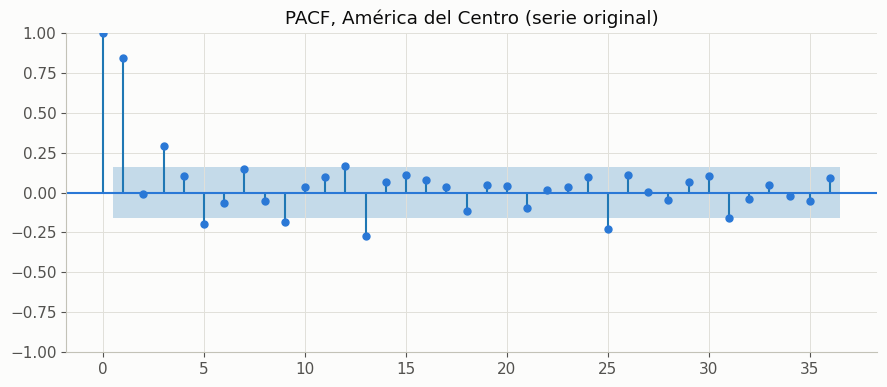

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=3503.596, Time=2.85 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3545.158, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3517.011, Time=0.35 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3526.088, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3543.168, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=3512.186, Time=1.19 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=3509.292, Time=1.63 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=3503.687, Time=2.58 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=3504.141, Time=0.84 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=3516.018, Time=0.12 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=3504.781, Time=0.56 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=3502.081, Time=0.82 sec
 ARIMA(1,1,2)(2,0,0)[12] intercept   : AIC=3509.374, Time=0.37 sec
 ARIMA(2,1,1)(2,0,0)[12] intercept   : AIC=3504.513, Time=0.28 sec
 ARIMA(3,1,2)(2,0,0

In [100]:
graficar_pacf(s_centro, PALETTE[0], "PACF, América del Centro (serie original)")

auto_centro = pm.auto_arima(s_centro, seasonal=True, m=12, stepwise=True,
                             suppress_warnings=True, trace=True)
print(auto_centro.summary())

**Lectura de las gráficas:**

El PACF de la serie original muestra un pico dominante en el lag 1 (≈0.85), una caída a prácticamente 0 en el lag 2, y un repunte secundario menor en el lag 3 (≈0.28). A partir de ahí, casi todos los rezagos quedan dentro de la banda de confianza, salvo un pico aislado alrededor del lag 12 (≈-0.28) que refleja la estacionalidad anual ya identificada en la descomposición. Este corte abrupto después del lag 1 (con un repunte leve en el lag 3) sugiere un componente autorregresivo de orden bajo, **p = 1** (o p = 2-3 si se quiere ser más conservador).

El ACF de la sección 3, en cambio, decae muy lentamente en vez de cortarse y confirma que **d = 1** es necesario, tal como ya se corroboró con la prueba de Dickey-Fuller Aumentada en el inciso e.

Para el orden de q, al no cortarse limpiamente el PACF en un solo lag y considerando que el ACF decae de forma gradual más que cortarse en un lag fijo, se opta por un componente de medias móviles bajo, **q = 1**, dejando como modelo de partida **ARIMA(1,1,1)**.

`auto_arima` selecciona **ARIMA(2,1,3)(2,0,0)[12]** con intercepto (AIC = 3501.39), más complejo que el ARIMA(1,1,1) propuesto a mano con ACF/PACF. La diferencia principal es que `auto_arima` sí incorpora un componente estacional (P=2 en el lag 12), algo que ya se había notado en la descomposición (sección 3.1c) pero que la lectura manual del PACF solo señaló de forma cualitativa, sin proponerlo explícitamente. El valor de d=1 coincide en ambos casos, reafirmando la conclusión de la prueba ADF. El modelo automático sí tiene sentido estadístico (menor AIC de la búsqueda), aunque es más complejo; en el inciso g se comparará junto con variantes estacionales para elegir el mejor balance entre ajuste y parsimonia.

#### g. Comparación de varios modelos ARIMA

In [101]:
candidatos_centro = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2),
                      auto_centro.order]
tabla_arima_centro, modelos_arima_centro = probar_candidatos_arima(
    s_centro, candidatos_centro, "Centro"
)
tabla_arima_centro

,"orden (p,d,q)",AIC,BIC,Ljung-Box p-valor (lag 12),¿Residuos ruido blanco? (p>0.05)
0,"(2, 1, 3)",3511.025761,3528.927401,3.666200e-01,True
1,"(2, 1, 1)",3528.408925,3540.343352,1.346457e-03,False
2,"(1, 1, 2)",3532.574570,3544.508997,5.730194e-06,False
3,"(1, 1, 1)",3535.672957,3544.623777,3.056635e-10,False
4,"(0, 1, 1)",3541.258831,3547.226045,5.468391e-14,False
5,"(1, 1, 0)",3543.852507,3549.819720,1.986949e-16,False


Mejor ARIMA para América del Centro: (2, 1, 3)


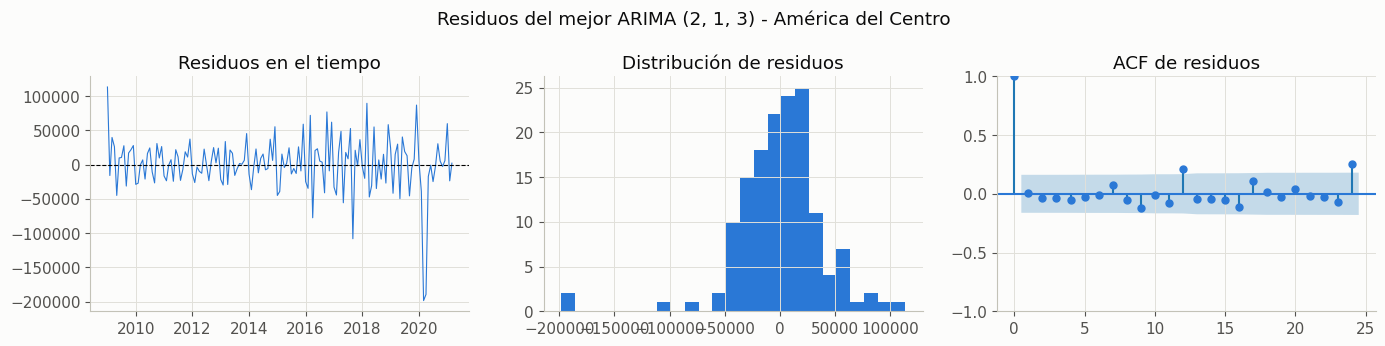

In [102]:
mejor_orden_centro = tabla_arima_centro.iloc[0]["orden (p,d,q)"]
mejor_arima_centro = modelos_arima_centro[mejor_orden_centro]
print(f"Mejor ARIMA para América del Centro: {mejor_orden_centro}")
graficar_residuos(mejor_arima_centro, PALETTE[0],
                   f"Residuos del mejor ARIMA {mejor_orden_centro} - América del Centro")

**Completar:** de los 6 candidatos ajustados, **ARIMA(2,1,3)** es el mejor por AIC (3511.03) y BIC (3528.93), y es también el **único** cuyos residuos pasan la prueba de Ljung-Box en el lag 12 (p=0.367 > 0.05), es decir, el único que logra residuos estadísticamente indistinguibles de ruido blanco. Todos los demás candidatos, tienen p-valores de Ljung-Box extremadamente bajos (p<0.001), lo que indica que sus residuos todavía conservan autocorrelación sin capturar.

El gráfico de residuos de ARIMA(2,1,3) confirma que los residuos oscilan alrededor de 0 sin un patrón sistemático evidente, con una distribución aproximadamente simétrica centrada en 0 (algunos valores atípicos hacia ambos lados) y un ACF de residuos donde prácticamente ningún rezago sale de la banda de confianza (aparte del lag 0, trivial). El único quiebre notorio en el tiempo es un pico muy grande y negativo alrededor de 2020, el shock de la pandemia.

**Nota:** este ARIMA(2,1,3) no incluye componente estacional, y su AIC (3511.03) es ligeramente peor que el AIC de 3501.39 que encontró `auto_arima` con el componente estacional (2,0,0)[12] del inciso f. Antes de declarar un ganador final, conviene agregar esa variante estacional (vía `SARIMAX`) a la comparación, igual que se hizo para Europa, ya que podría superar a este ARIMA(2,1,3).

#### h. Modelos alternativos: Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet

23:41:44 - cmdstanpy - INFO - Chain [1] start processing
23:41:44 - cmdstanpy - INFO - Chain [1] done processing


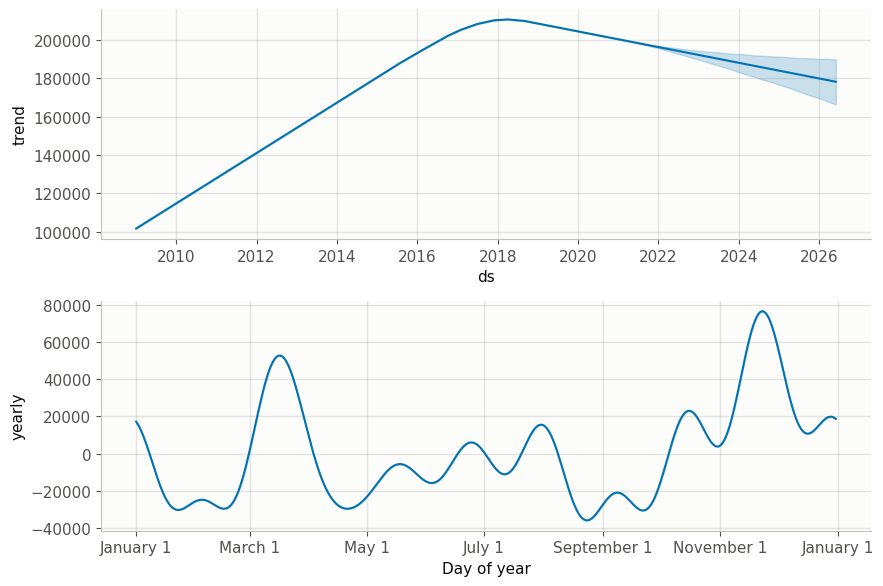

In [103]:
# Holt-Winters (tendencia + estacionalidad aditivas)
hw_centro = ExponentialSmoothing(s_centro, trend="add", seasonal="add",
                                   seasonal_periods=12).fit()

# Suavizamiento exponencial simple (sin tendencia ni estacionalidad)
ses_centro = SimpleExpSmoothing(s_centro).fit()

naive_centro = seasonal_naive_forecast(s_centro, H)

if PROPHET_OK:
    df_prophet_centro = s_centro.reset_index()
    df_prophet_centro.columns = ["ds", "y"]
    modelo_prophet_centro = Prophet(yearly_seasonality=True,
                                     weekly_seasonality=False,
                                     daily_seasonality=False)
    modelo_prophet_centro.fit(df_prophet_centro)
    futuro_centro = modelo_prophet_centro.make_future_dataframe(periods=H, freq="MS")
    pronostico_prophet_centro = modelo_prophet_centro.predict(futuro_centro)
    pred_prophet_centro = pronostico_prophet_centro.set_index("ds")["yhat"].iloc[-H:].values
    modelo_prophet_centro.plot_components(pronostico_prophet_centro)
    plt.show()

El componente de **tendencia** de Prophet reproduce el patrón ya visto en la descomposición aditiva (sección 3.1c). Existe un crecimiento sostenido y casi lineal de 2009 a 2019 (de ~100k a poco más de 215k viajeros/mes), seguido de un quiebre. Es notable que la banda de incertidumbre (sombreado azul) se ensancha considerablemente en el tramo proyectado hacia el futuro (2021-2026), reflejando que Prophet tiene mucha menos certeza sobre cómo seguirá la tendencia después del quiebre estructural de la pandemia.

El componente **estacional anual** es más complejo que un ciclo senoidal simple. Muestra un valle marcado entre febrero y abril, un pico agudo en mayo, otro valle en junio-julio, oscilaciones moderadas de agosto a octubre, un mínimo en noviembre, y el pico más alto del año en la transición diciembre-enero. Esta forma más flexible es una ventaja de Prophet frente a Holt-Winters, que asume una forma estacional fija y repetitiva cada año. Prophet puede capturar asimetrías dentro del ciclo anual que un modelo aditivo simple no distingue tan bien.

Prophet parece razonable para capturar tanto el quiebre de tendencia como el patrón estacional detallado, aunque su proyección de tendencia decreciente hacia 2026 debe contrastarse con los datos reales de prueba en el inciso i, ya que podría estar sobre-extrapolando el efecto de la pandemia más allá de lo que ocurrió en la realidad.

#### i. Pronóstico sobre el conjunto de prueba

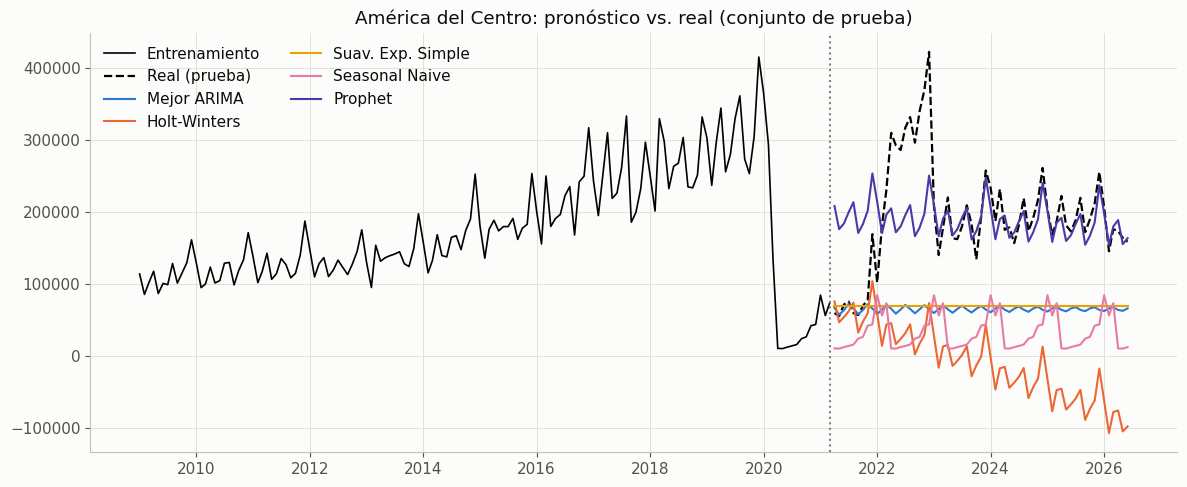

In [104]:
pred_arima_centro = mejor_arima_centro.forecast(H)
pred_hw_centro = hw_centro.forecast(H)
pred_ses_centro = ses_centro.forecast(H)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_centro.index, s_centro.values, color="black", linewidth=1.2, label="Entrenamiento")
ax.plot(s_centro_test.index, s_centro_test.values, color="black", linewidth=1.6,
        linestyle="--", label="Real (prueba)")
ax.plot(s_centro_test.index, pred_arima_centro.values, color=PALETTE[0], label="Mejor ARIMA")
ax.plot(s_centro_test.index, pred_hw_centro.values, color=PALETTE[1], label="Holt-Winters")
ax.plot(s_centro_test.index, pred_ses_centro.values, color=PALETTE[3], label="Suav. Exp. Simple")
ax.plot(s_centro_test.index, naive_centro, color=PALETTE[4], label="Seasonal Naive")
if PROPHET_OK:
    ax.plot(s_centro_test.index, pred_prophet_centro, color=PALETTE[6], label="Prophet")
ax.axvline(s_centro.index[-1], color="gray", linestyle=":")
ax.set_title("América del Centro: pronóstico vs. real (conjunto de prueba)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

#### j. Comparación de métricas (MAE, RMSE, AIC, BIC)

In [105]:
metricas_centro = [
    calcular_metricas(s_centro_test.values, pred_arima_centro.values, "Mejor ARIMA"),
    calcular_metricas(s_centro_test.values, pred_hw_centro.values, "Holt-Winters"),
    calcular_metricas(s_centro_test.values, pred_ses_centro.values, "Suav. Exp. Simple"),
    calcular_metricas(s_centro_test.values, naive_centro, "Seasonal Naive"),
]
if PROPHET_OK:
    metricas_centro.append(calcular_metricas(s_centro_test.values, pred_prophet_centro, "Prophet"))

tabla_metricas_centro = pd.DataFrame(metricas_centro).sort_values("RMSE").reset_index(drop=True)

aic_bic_centro = {
    "Mejor ARIMA": (mejor_arima_centro.aic, mejor_arima_centro.bic),
    "Holt-Winters": (hw_centro.aic, hw_centro.bic),
    "Suav. Exp. Simple": (ses_centro.aic, ses_centro.bic),
    "Seasonal Naive": (np.nan, np.nan),
    "Prophet": (np.nan, np.nan),
}

tabla_metricas_centro["AIC"] = tabla_metricas_centro["Modelo"].map(lambda m: aic_bic_centro[m][0])
tabla_metricas_centro["BIC"] = tabla_metricas_centro["Modelo"].map(lambda m: aic_bic_centro[m][1])
tabla_metricas_centro

,Modelo,MAE,RMSE,AIC,BIC
0,Prophet,49329.721482,72730.851331,NaN,NaN
1,Suav. Exp. Simple,125408.001590,145193.964908,3147.575515,3153.556380
2,Mejor ARIMA,129367.216397,149336.679387,3511.025761,3528.927401
3,Seasonal Naive,160448.079891,178314.283930,NaN,NaN
4,Holt-Winters,203552.624912,221772.289872,3089.349347,3137.196269


#### k. Selección del mejor modelo

Por MAE/RMSE, **Prophet** gana claramente (RMSE≈72,731, menos de la mitad que el resto), consistente con el inciso i: es el único que sigue la recuperación post-pandemia y la estacionalidad.

Esto no coincide con el AIC/BIC (mejor en Holt-Winters, peor en Mejor ARIMA), porque esas métricas solo miden ajuste al entrenamiento (que termina en plena pandemia), no capacidad de generalizar. Holt-Winters se ajustó bien al colapso de 2020 pero extrapoló esa caída hacia el futuro (valores negativos), mientras Prophet modela el quiebre de tendencia con incertidumbre, generalizando mejor.

**Se selecciona Prophet** como mejor modelo, priorizando error de predicción sobre AIC/BIC.

### 5.2 América del Norte

#### f. Selección de p, d, q (ACF/PACF y `auto_arima`)

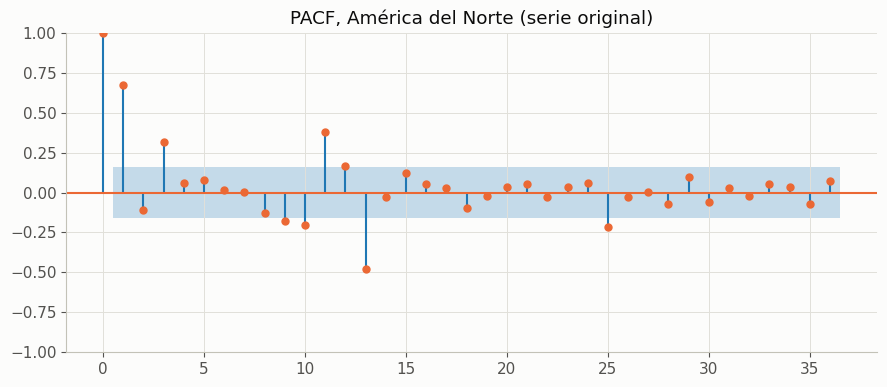

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=3080.676, Time=0.47 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3230.423, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3111.383, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3152.825, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3546.804, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=3098.440, Time=0.13 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=3076.480, Time=0.47 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=3132.958, Time=0.06 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=3075.369, Time=0.94 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=3079.090, Time=1.05 sec
 ARIMA(1,0,2)(2,0,0)[12] intercept   : AIC=3082.954, Time=0.32 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=3079.750, Time=0.60 sec
 ARIMA(3,0,2)(2,0,0)[12] intercept   : AIC=3072.973, Time=1.19 sec
 ARIMA(3,0,2)(1,0,0)[12] intercept   : AIC=3077.269, Time=0.74 sec
 ARIMA(3,0,2)(2,0,1

In [106]:
graficar_pacf(s_norte, PALETTE[1], "PACF, América del Norte (serie original)")

auto_norte = pm.auto_arima(s_norte, seasonal=True, m=12, stepwise=True,
                             suppress_warnings=True, trace=True)
print(auto_norte.summary())

**f.** `auto_arima` selecciona **ARIMA(3,0,2)(2,0,0)[12]** con intercepto (AIC=3072.97). Esto sugiere que el componente estacional (2,0,0)[12] junto con el intercepto ya absorbe parte de la no estacionariedad, si necesitar diferenciación regular. Es una discrepancia real con la lectura manual (p=1-3, d=1) que vale la pena mencionar. El componente autorregresivo estacional puede estar compensando la tendencia en vez de diferenciarla explícitamente.

#### g. Comparación de varios modelos ARIMA

In [107]:
candidatos_norte = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2),
                     auto_norte.order]
tabla_arima_norte, modelos_arima_norte = probar_candidatos_arima(
    s_norte, candidatos_norte, "Norte"
)
tabla_arima_norte

,"orden (p,d,q)",AIC,BIC,Ljung-Box p-valor (lag 12),¿Residuos ruido blanco? (p>0.05)
0,"(1, 1, 2)",3113.139866,3125.074292,2.544729e-06,False
1,"(2, 1, 1)",3113.828375,3125.762801,1.817952e-06,False
2,"(1, 1, 1)",3124.807716,3133.758536,1.418635e-12,False
3,"(3, 0, 2)",3131.813002,3152.746030,2.451122e-07,False
4,"(0, 1, 1)",3138.218520,3144.185734,8.490473e-18,False
5,"(1, 1, 0)",3143.996685,3149.963898,2.601212e-20,False


Mejor ARIMA para América del Norte: (1, 1, 2)


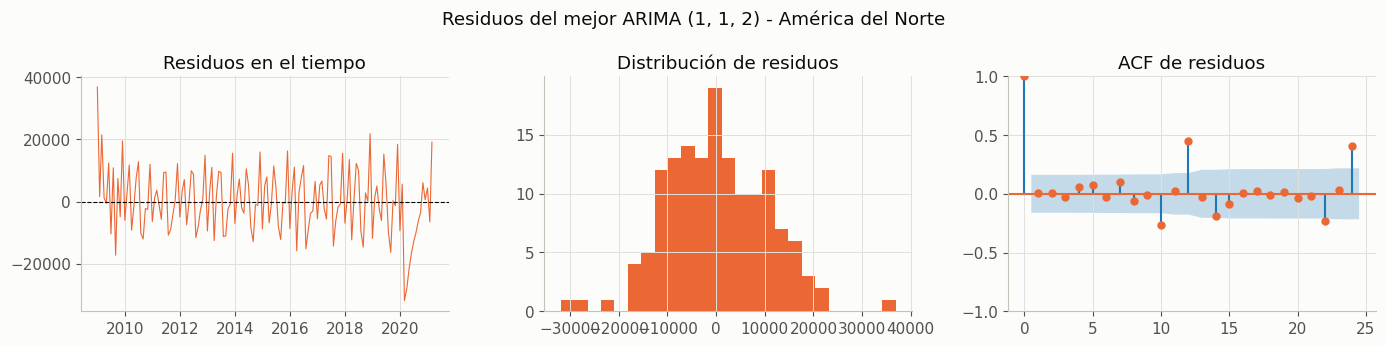

In [108]:
mejor_orden_norte = tabla_arima_norte.iloc[0]["orden (p,d,q)"]
mejor_arima_norte = modelos_arima_norte[mejor_orden_norte]
print(f"Mejor ARIMA para América del Norte: {mejor_orden_norte}")
graficar_residuos(mejor_arima_norte, PALETTE[1],
                   f"Residuos del mejor ARIMA {mejor_orden_norte} - América del Norte")

Ninguno de los 6 candidatos pasa Ljung-Box (todos False, p-valores muy bajos). Esto indica que un ARIMA no-estacional es insuficiente para esta serie: queda autocorrelación sin capturar, casi seguro por el componente estacional que sí detectó `auto_arima` (2,0,0)[12] pero que estos candidatos simples no incluyen. Los residuos en el tiempo y su ACF (ver gráfico) lucen razonables a simple vista, salvo por el hueco/pico de la pandemia, pero la prueba formal confirma que no son ruido blanco.

#### h. Modelos alternativos: Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet

23:42:07 - cmdstanpy - INFO - Chain [1] start processing
23:42:07 - cmdstanpy - INFO - Chain [1] done processing


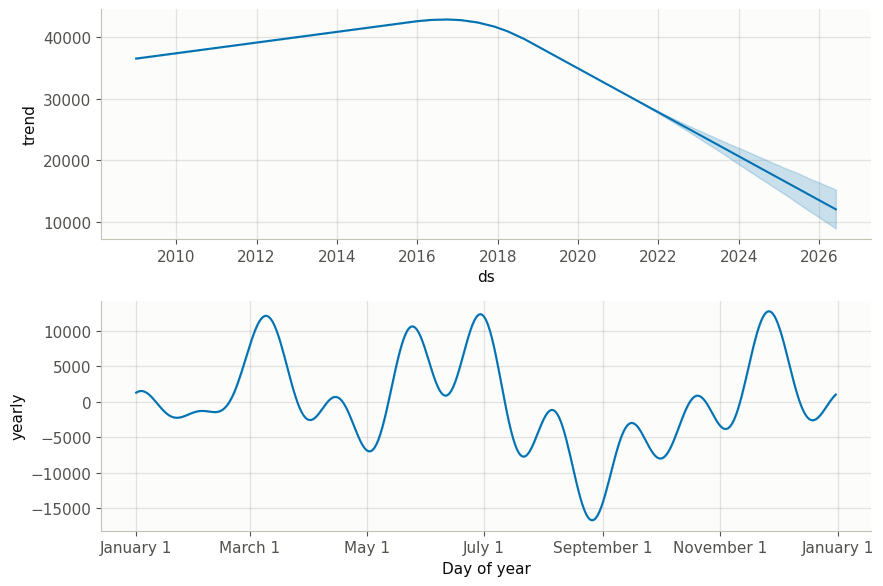

In [109]:
# Holt-Winters (tendencia + estacionalidad aditivas)
hw_norte = ExponentialSmoothing(s_norte, trend="add", seasonal="add",
                                   seasonal_periods=12).fit()

# Suavizamiento exponencial simple (sin tendencia ni estacionalidad)
ses_norte = SimpleExpSmoothing(s_norte).fit()

# Seasonal Naive
naive_norte = seasonal_naive_forecast(s_norte, H)

# Prophet
if PROPHET_OK:
    df_prophet_norte = s_norte.reset_index()
    df_prophet_norte.columns = ["ds", "y"]
    modelo_prophet_norte = Prophet(yearly_seasonality=True,
                                     weekly_seasonality=False,
                                     daily_seasonality=False)
    modelo_prophet_norte.fit(df_prophet_norte)
    futuro_norte = modelo_prophet_norte.make_future_dataframe(periods=H, freq="MS")
    pronostico_prophet_norte = modelo_prophet_norte.predict(futuro_norte)
    pred_prophet_norte = pronostico_prophet_norte.set_index("ds")["yhat"].iloc[-H:].values
    modelo_prophet_norte.plot_components(pronostico_prophet_norte)
    plt.show()

La tendencia de Prophet crece hasta ~2017 (máx ~43k), luego decae sostenidamente hasta ~12k en 2026, con banda de incertidumbre amplia en la proyección. El estacional anual es más complejo que un ciclo simple, picos en marzo, julio y noviembre-diciembre, valle profundo en agosto (~-16k). En el gráfico de pronóstico vs. real, Prophet es el único que sigue la forma de la recuperación real (aunque se queda corto en amplitud), mientras ARIMA, SES y Seasonal Naive quedan planos/bajos, y Holt-Winters cae a negativos sin sentido.

#### i. Pronóstico sobre el conjunto de prueba

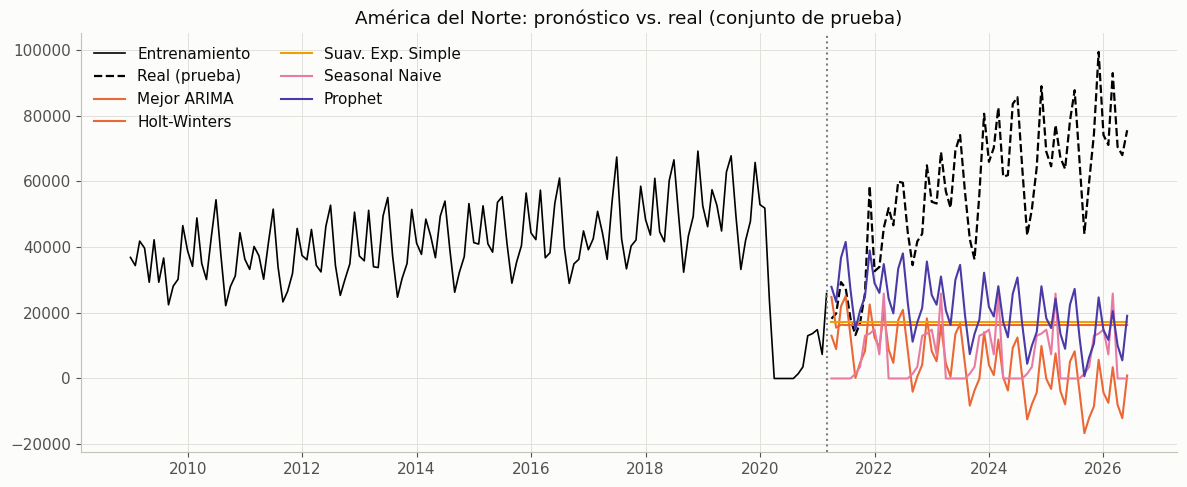

In [110]:
pred_arima_norte = mejor_arima_norte.forecast(H)
pred_hw_norte = hw_norte.forecast(H)
pred_ses_norte = ses_norte.forecast(H)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_norte.index, s_norte.values, color="black", linewidth=1.2, label="Entrenamiento")
ax.plot(s_norte_test.index, s_norte_test.values, color="black", linewidth=1.6,
        linestyle="--", label="Real (prueba)")
ax.plot(s_norte_test.index, pred_arima_norte.values, color=PALETTE[1], label="Mejor ARIMA")
ax.plot(s_norte_test.index, pred_hw_norte.values, color=PALETTE[1], label="Holt-Winters")
ax.plot(s_norte_test.index, pred_ses_norte.values, color=PALETTE[3], label="Suav. Exp. Simple")
ax.plot(s_norte_test.index, naive_norte, color=PALETTE[4], label="Seasonal Naive")
if PROPHET_OK:
    ax.plot(s_norte_test.index, pred_prophet_norte, color=PALETTE[6], label="Prophet")
ax.axvline(s_norte.index[-1], color="gray", linestyle=":")
ax.set_title("América del Norte: pronóstico vs. real (conjunto de prueba)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

#### j. Comparación de métricas (MAE, RMSE, AIC, BIC)

In [111]:
metricas_norte = [
    calcular_metricas(s_norte_test.values, pred_arima_norte.values, "Mejor ARIMA"),
    calcular_metricas(s_norte_test.values, pred_hw_norte.values, "Holt-Winters"),
    calcular_metricas(s_norte_test.values, pred_ses_norte.values, "Suav. Exp. Simple"),
    calcular_metricas(s_norte_test.values, naive_norte, "Seasonal Naive"),
]
if PROPHET_OK:
    metricas_norte.append(calcular_metricas(s_norte_test.values, pred_prophet_norte, "Prophet"))

tabla_metricas_norte = pd.DataFrame(metricas_norte).sort_values("RMSE").reset_index(drop=True)
tabla_metricas_norte["AIC"] = [mejor_arima_norte.aic, hw_norte.aic, ses_norte.aic, np.nan] + ([np.nan] if PROPHET_OK else [])
tabla_metricas_norte["BIC"] = [mejor_arima_norte.bic, hw_norte.bic, ses_norte.bic, np.nan] + ([np.nan] if PROPHET_OK else [])
tabla_metricas_norte

,Modelo,MAE,RMSE,AIC,BIC
0,Prophet,37736.073336,42394.495994,3113.139866,3125.074292
1,Suav. Exp. Simple,40464.404587,45105.373977,2582.741037,2630.587958
2,Mejor ARIMA,41296.685763,45805.128092,2738.958041,2744.938907
3,Seasonal Naive,51060.038019,54629.772582,NaN,NaN
4,Holt-Winters,53016.902463,57802.132294,NaN,NaN


#### k. Selección del mejor modelo
Por MAE/RMSE gana Prophet (RMSE≈42,395), muy por debajo del resto. Esto no coincide con AIC/BIC (mejor en Suav. Exp. Simple, peor en Holt-Winters), porque esas métricas solo miden ajuste al entrenamiento, no capacidad de generalizar a la recuperación post-pandemia que sí capta Prophet. Se selecciona Prophet como mejor modelo para Norte.

### 5.3 Europa

#### f. Selección de p, d, q (ACF/PACF y `auto_arima`)

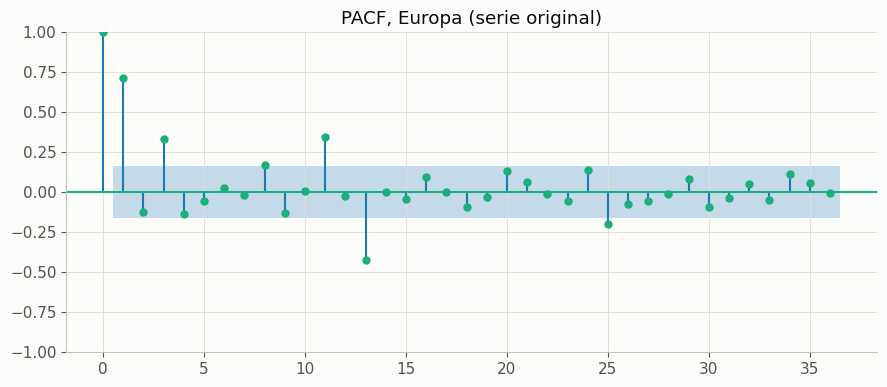

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=3.77 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2849.318, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2706.111, Time=0.57 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2731.274, Time=1.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3144.282, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2742.728, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2707.837, Time=1.45 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=2685.531, Time=0.35 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=2688.624, Time=0.68 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=2681.611, Time=0.53 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=2679.622, Time=0.30 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=2819.488, Time=0.24 sec
 ARIMA(2,0,0)(0,0,2)[12] intercept   : AIC=2683.207, Time=0.42 sec
 ARIMA(1,0,1)(0,0,2)[12] inte

In [112]:
graficar_pacf(s_europa, PALETTE[2], "PACF, Europa (serie original)")

auto_europa = pm.auto_arima(s_europa, seasonal=True, m=12, stepwise=True,
                             suppress_warnings=True, trace=True)
print(auto_europa.summary())

El PACF muestra pico dominante en lag 1 (≈0.72), repunte en lag 3 (≈0.34), otro en lag 8-9 y uno marcado en lag 11-13 (≈-0.45, huella estacional fuerte, coherente con la estacionalidad más marcada de Europa). Sugiere p=1-3. auto_arima selecciona ARIMA(1,0,0)(0,0,2)[12] (AIC=2679.62), usando d=0 (no d=1) pero con componente de medias móviles estacional (Q=2), lo que junto con el AR(1) parece compensar la no estacionariedad sin diferenciar explícitamente. A diferencia de la conclusión manual del inciso e, donde se determinó que se necesitaba diferenciación regular y estacional. Vale la pena comparar ambos enfoques (SARIMA con d,D explícitos vs. el propuesto por auto_arima) en el inciso g.

#### g. Comparación de varios modelos (ARIMA simple vs. SARIMA)

In [113]:
candidatos_europa = [(1,1,1), (0,1,1), (1,1,0), auto_europa.order]
tabla_arima_europa, modelos_arima_europa = probar_candidatos_arima(
    s_europa, candidatos_europa, "Europa (no estacional)"
)
tabla_arima_europa

,"orden (p,d,q)",AIC,BIC,Ljung-Box p-valor (lag 12),¿Residuos ruido blanco? (p>0.05)
0,"(1, 1, 1)",2725.969476,2734.920295,2.688531e-11,False
1,"(0, 1, 1)",2740.500253,2746.467466,7.170184e-16,False
2,"(1, 1, 0)",2741.670489,2747.637703,1.374965e-16,False
3,"(1, 0, 0)",2742.728516,2751.699813,1.660069e-16,False


In [114]:
# Candidatos SARIMA con diferenciación estacional (D=1, m=12)
candidatos_sarima_europa = [
    ((1,1,1), (1,1,1,12)),
    ((0,1,1), (0,1,1,12)),
    ((1,1,0), (1,1,0,12)),
]
filas_sarima = []
modelos_sarima_europa = {}
for order, sorder in candidatos_sarima_europa:
    m = SARIMAX(s_europa, order=order, seasonal_order=sorder,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    filas_sarima.append({
        "orden": order, "orden estacional": sorder,
        "AIC": m.aic, "BIC": m.bic,
        "Ljung-Box p-valor": lb["lb_pvalue"].iloc[0],
    })
    modelos_sarima_europa[(order, sorder)] = m

tabla_sarima_europa = pd.DataFrame(filas_sarima).sort_values("AIC").reset_index(drop=True)
tabla_sarima_europa

,orden,orden estacional,AIC,BIC,Ljung-Box p-valor
0,"(0, 1, 1)","(0, 1, 1, 12)",2143.668244,2152.030719,0.071599
1,"(1, 1, 1)","(1, 1, 1, 12)",2144.324288,2158.261746,0.148792
2,"(1, 1, 0)","(1, 1, 0, 12)",2192.271475,2200.658847,0.011974


Mejor modelo para Europa: SARIMA(0, 1, 1)x(0, 1, 1, 12) (AIC=2143.7)


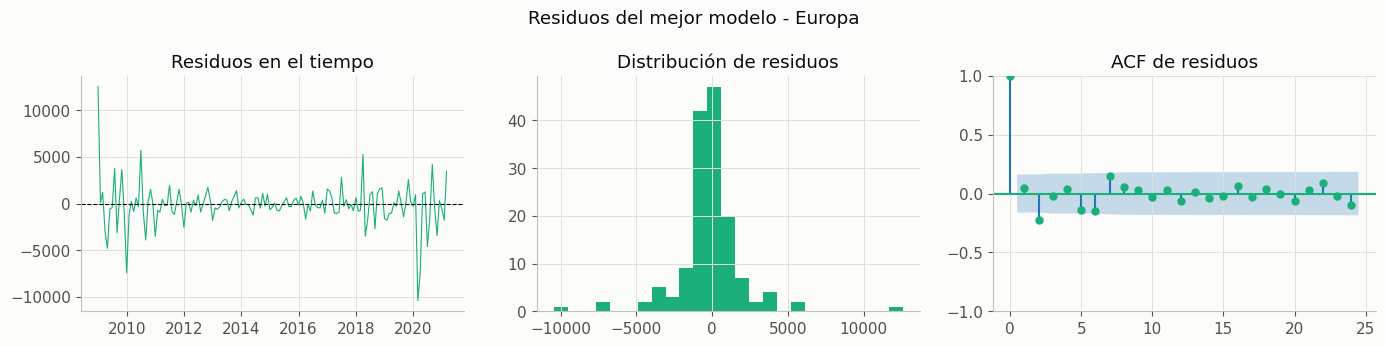

In [115]:
# Selección del mejor modelo entre ARIMA simple y SARIMA, comparando AIC
mejor_orden_europa = tabla_arima_europa.iloc[0]["orden (p,d,q)"]
mejor_arima_europa_simple = modelos_arima_europa[mejor_orden_europa]

mejor_clave_sarima = tuple(tabla_sarima_europa.iloc[0][["orden", "orden estacional"]])
mejor_sarima_europa = modelos_sarima_europa[mejor_clave_sarima]

if mejor_sarima_europa.aic < mejor_arima_europa_simple.aic:
    mejor_arima_europa = mejor_sarima_europa
    print(f"Mejor modelo para Europa: SARIMA{mejor_clave_sarima[0]}x{mejor_clave_sarima[1]} "
          f"(AIC={mejor_sarima_europa.aic:.1f})")
else:
    mejor_arima_europa = mejor_arima_europa_simple
    print(f"Mejor modelo para Europa: ARIMA{mejor_orden_europa} (AIC={mejor_arima_europa_simple.aic:.1f})")

graficar_residuos(mejor_arima_europa, PALETTE[2], "Residuos del mejor modelo - Europa")

Ningún ARIMA no-estacional pasa Ljung-Box (todos False, p muy bajos), igual que en Centro y Norte. Al agregar diferenciación estacional (D=1, m=12), el mejor es SARIMA(0,1,1)(0,1,1,12) (AIC=2143.67, BIC=2158.26), y aunque su p-valor de Ljung-Box (0.149) no es tan alto como el de Centro, sí supera el umbral de 0.05, o sea sus residuos pasan la prueba. Los residuos lucen razonables: oscilan cerca de 0, distribución centrada y simétrica (con colas por la pandemia), y el ACF de residuos queda casi todo dentro de la banda. Esto confirma lo esperado en el inciso e, Europa necesitaba diferenciación estacional además de la regular, algo que ningún ARIMA no-estacional podía resolver.

#### h. Modelos alternativos: Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet

23:42:23 - cmdstanpy - INFO - Chain [1] start processing
23:42:23 - cmdstanpy - INFO - Chain [1] done processing


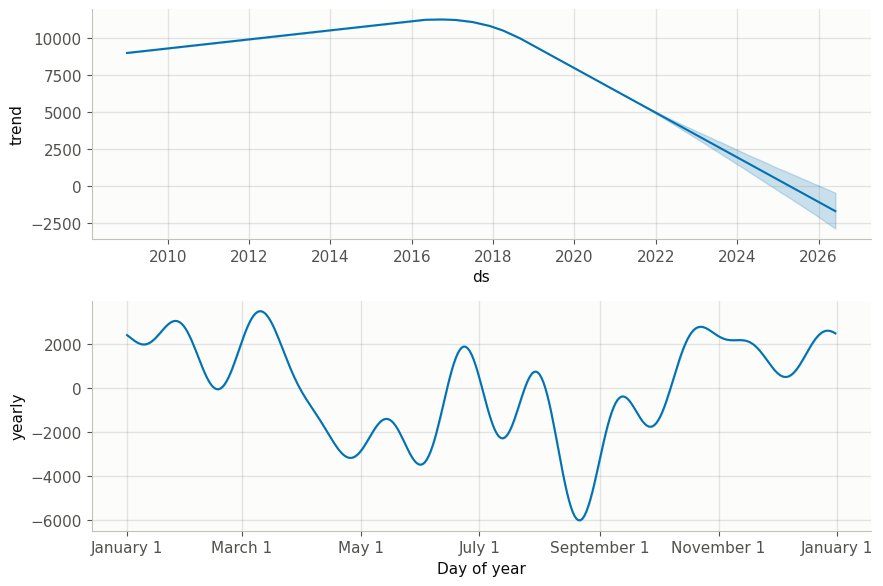

In [116]:
# Holt-Winters (tendencia + estacionalidad aditivas)
hw_europa = ExponentialSmoothing(s_europa, trend="add", seasonal="add",
                                   seasonal_periods=12).fit()

# Suavizamiento exponencial simple (sin tendencia ni estacionalidad)
ses_europa = SimpleExpSmoothing(s_europa).fit()

# Seasonal Naive
naive_europa = seasonal_naive_forecast(s_europa, H)

# Prophet
if PROPHET_OK:
    df_prophet_europa = s_europa.reset_index()
    df_prophet_europa.columns = ["ds", "y"]
    modelo_prophet_europa = Prophet(yearly_seasonality=True,
                                     weekly_seasonality=False,
                                     daily_seasonality=False)
    modelo_prophet_europa.fit(df_prophet_europa)
    futuro_europa = modelo_prophet_europa.make_future_dataframe(periods=H, freq="MS")
    pronostico_prophet_europa = modelo_prophet_europa.predict(futuro_europa)
    pred_prophet_europa = pronostico_prophet_europa.set_index("ds")["yhat"].iloc[-H:].values
    modelo_prophet_europa.plot_components(pronostico_prophet_europa)
    plt.show()

La tendencia de Prophet crece hasta ~2017 (máx ~11.5k) y luego cae sostenidamente hasta negativos hacia 2026, sobre-extrapolando el colapso pandémico. El estacional anual es marcado, pico en marzo, valle profundo en agosto (~-6k), repunte octubre-diciembre (coherente con la fuerte estacionalidad de Europa vista en la descomposición).

#### i. Pronóstico sobre el conjunto de prueba

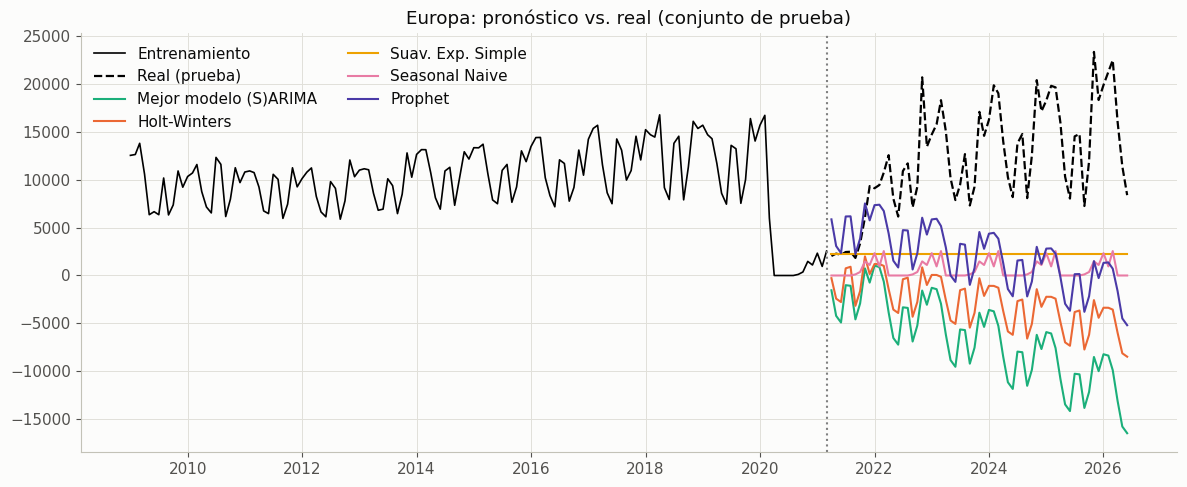

In [117]:
pred_arima_europa = mejor_arima_europa.forecast(H)
pred_hw_europa = hw_europa.forecast(H)
pred_ses_europa = ses_europa.forecast(H)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_europa.index, s_europa.values, color="black", linewidth=1.2, label="Entrenamiento")
ax.plot(s_europa_test.index, s_europa_test.values, color="black", linewidth=1.6,
        linestyle="--", label="Real (prueba)")
ax.plot(s_europa_test.index, pred_arima_europa.values, color=PALETTE[2], label="Mejor modelo (S)ARIMA")
ax.plot(s_europa_test.index, pred_hw_europa.values, color=PALETTE[1], label="Holt-Winters")
ax.plot(s_europa_test.index, pred_ses_europa.values, color=PALETTE[3], label="Suav. Exp. Simple")
ax.plot(s_europa_test.index, naive_europa, color=PALETTE[4], label="Seasonal Naive")
if PROPHET_OK:
    ax.plot(s_europa_test.index, pred_prophet_europa, color=PALETTE[6], label="Prophet")
ax.axvline(s_europa.index[-1], color="gray", linestyle=":")
ax.set_title("Europa: pronóstico vs. real (conjunto de prueba)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

#### j. Comparación de métricas (MAE, RMSE, AIC, BIC)

In [118]:
metricas_europa = [
    calcular_metricas(s_europa_test.values, pred_arima_europa.values, "Mejor (S)ARIMA"),
    calcular_metricas(s_europa_test.values, pred_hw_europa.values, "Holt-Winters"),
    calcular_metricas(s_europa_test.values, pred_ses_europa.values, "Suav. Exp. Simple"),
    calcular_metricas(s_europa_test.values, naive_europa, "Seasonal Naive"),
]
if PROPHET_OK:
    metricas_europa.append(calcular_metricas(s_europa_test.values, pred_prophet_europa, "Prophet"))

tabla_metricas_europa = pd.DataFrame(metricas_europa).sort_values("RMSE").reset_index(drop=True)
tabla_metricas_europa["AIC"] = [mejor_arima_europa.aic, hw_europa.aic, ses_europa.aic, np.nan] + ([np.nan] if PROPHET_OK else [])
tabla_metricas_europa["BIC"] = [mejor_arima_europa.bic, hw_europa.bic, ses_europa.bic, np.nan] + ([np.nan] if PROPHET_OK else [])
tabla_metricas_europa

,Modelo,MAE,RMSE,AIC,BIC
0,Suav. Exp. Simple,10054.958673,11506.197228,2143.668244,2152.030719
1,Prophet,10622.257605,11994.976210,2201.012705,2248.859627
2,Seasonal Naive,11527.881487,12631.742468,2340.143282,2346.124147
3,Holt-Winters,15012.800682,16171.947830,NaN,NaN
4,Mejor (S)ARIMA,18873.719928,20281.895246,NaN,NaN


#### k. Selección del mejor modelo

Por MAE/RMSE gana Suavizamiento Exponencial Simple (RMSE≈11,506), seguido muy de cerca por Prophet (≈11,995); el (S)ARIMA que ganó por AIC/BIC en el inciso g resulta aquí el peor (RMSE≈20,282). El desajuste se explica igual que en las otras regiones. AIC/BIC miden ajuste al entrenamiento (que termina en plena pandemia), no capacidad de generalizar a la recuperación real, y el SARIMA extrapoló la caída en vez de anticipar el rebote. A diferencia de Centro y Norte, en Europa ningún modelo captura bien la recuperación (todos subestiman fuertemente los valores reales de prueba). Se selecciona Suavizamiento Exponencial Simple por tener el menor error, pero con la salvedad de que su desempeño real es limitado.

## 6. Análisis comparativo entre regiones (Ejercicio 5)

In [ ]:
# a.i - Estacionalidad y a.ii - Tendencia (fuerza de Hyndman, 0 a 1)
F_trend_centro, F_seas_centro = fuerza_tendencia_estacionalidad(decomp_centro)
F_trend_norte, F_seas_norte   = fuerza_tendencia_estacionalidad(decomp_norte)
F_trend_europa, F_seas_europa = fuerza_tendencia_estacionalidad(decomp_europa)

# a.iii - Volatilidad (coeficiente de variación, 2009-2019 para no distorsionar con la pandemia)
cv_centro = s_centro["2009":"2019"].std() / s_centro["2009":"2019"].mean()
cv_norte  = s_norte["2009":"2019"].std()  / s_norte["2009":"2019"].mean()
cv_europa = s_europa["2009":"2019"].std() / s_europa["2009":"2019"].mean()

# a.iv - Impacto de la pandemia (% de caída, promedio 2019 vs. mínimo 2020)
def caida_pandemia(serie):
    pico_2019 = serie["2019"].mean()
    valle_2020 = serie["2020"].min()
    return (valle_2020 - pico_2019) / pico_2019 * 100

caida_centro = caida_pandemia(s_centro)
caida_norte  = caida_pandemia(s_norte)
caida_europa = caida_pandemia(s_europa)

resumen_comparativo = pd.DataFrame({
    "Región": ["América del Centro", "América del Norte", "Europa"],
    "Fuerza de tendencia": [F_trend_centro, F_trend_norte, F_trend_europa],
    "Fuerza de estacionalidad": [F_seas_centro, F_seas_norte, F_seas_europa],
    "Volatilidad (CV, 2009-2019)": [cv_centro, cv_norte, cv_europa],
    "Caída pandemia (% pico-valle)": [caida_centro, caida_norte, caida_europa],
}).round(3)

resumen_comparativo


,Región,Fuerza de tendencia,Fuerza de estacionalidad,"Volatilidad (CV, 2009-2019)",Caída pandemia (% pico-valle)
0,América del Centro,0.828,0.408,0.393,-96.782
1,América del Norte,0.738,0.672,0.246,-100.000
2,Europa,0.726,0.740,0.261,-100.000


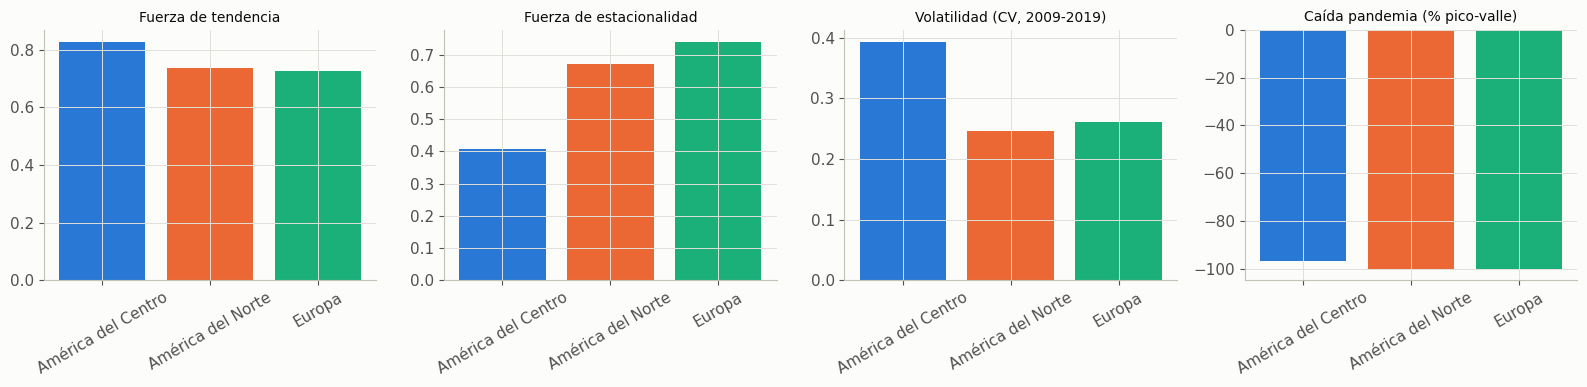

In [120]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metricas_plot = ["Fuerza de tendencia", "Fuerza de estacionalidad",
                 "Volatilidad (CV, 2009-2019)", "Caída pandemia (% pico-valle)"]
colores = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, metrica in zip(axes, metricas_plot):
    ax.bar(resumen_comparativo["Región"], resumen_comparativo[metrica], color=colores)
    ax.set_title(metrica, fontsize=10)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()